# 08 — Climate Projections (NEX-GDDP-CMIP6 Delta Method)

Project current ERA5-Land climate features forward 10–20 years using CMIP6 model output.

## Method
**Delta (change-factor) bias correction** adds the GCM change signal to the
high-resolution ERA5-Land baseline:



## Data pipeline
**All heavy compute runs on Google Earth Engine** (same as notebooks 05 / 04_ndvi).
The GEE asset  contains daily pr / tasmin / tasmax for all
CMIP6 models 1950–2100 at 0.25°.

| Step | Where it runs |
|---|---|
| Monthly-mean reduction to cell centroids | GEE (export tasks → Drive) |
| Download CSVs | Manual: Drive →  |
| Delta computation + feature derivation | Local (fast, small CSVs) |

## Horizons
| Label | GCM future period | Represents |
|---|---|---|
|  | 2026–2045 | ~10 years out |
|  | 2036–2055 | ~20 years out |

GCM historical reference: 2001–2014

## Outputs
- 
- 


In [1]:
import ee
import os, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
print('Imports OK')


/home/simonhans/anaconda3/lib/python3.7/site-packages/google/auth/crypt/_cryptography_rsa.py:22: CryptographyDeprecationWarning: Python 3.7 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.7.
  import cryptography.exceptions
/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


Imports OK


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────

DATA      = '../data'
PROJ_DIR  = os.path.join(DATA, 'climate_projections')   # cache for GEE CSVs
os.makedirs(PROJ_DIR, exist_ok=True)

# Five CMIP6 models available in NASA/NEX-GDDP-CMIP6 GEE asset
MODELS = [
    'ACCESS-CM2',
    'GFDL-ESM4',
    'MPI-ESM1-2-HR',
    'NorESM2-MM',
    'IPSL-CM6A-LR',
]

SCENARIOS = ['ssp245', 'ssp585']

# GEE NEX-GDDP-CMIP6 has pr, tasmin, tasmax (daily, K / kg m-2 s-1)
# No 'tas' band — approximate mean as (tasmin + tasmax) / 2
GCM_BANDS = ['pr', 'tasmin', 'tasmax']

HIST_YEARS   = (2001, 2014)
HORIZONS = {
    '2035': (2026, 2045),
    '2045': (2036, 2055),
}

# ERA5-Land feature derivation constants (match notebook 05)
DRY_MONTHS  = [6, 7, 8, 9]
COLD_THRESH = 10.0
HEAT_THRESH = 30.0
GDD_BASE    = 10.0

print('Config set.')
print(f'  Models   : {MODELS}')
print(f'  Scenarios: {SCENARIOS}')
print(f'  Horizons : { {k: f"{v[0]}-{v[1]}" for k, v in HORIZONS.items()} }')


Config set.
  Models   : ['ACCESS-CM2', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'NorESM2-MM', 'IPSL-CM6A-LR']
  Scenarios: ['ssp245', 'ssp585']
  Horizons : {'2035': '2026-2045', '2045': '2036-2055'}


In [3]:
# ── GEE authentication + cell FeatureCollection ──────────────────────────────
# Same setup as notebook 05: authenticate once, build hex-cell FC from
# plot_elev_features.pkl centroids.

ee.Authenticate()
ee.Initialize(project='ee-simonhansedasi')
print('GEE authenticated.')

from shapely.geometry import mapping

elev_feat = pd.read_pickle(f'{DATA}/plot_elev_features.pkl')
gdf_all   = gpd.GeoDataFrame(elev_feat[['plot_id', 'geometry']], geometry='geometry', crs='EPSG:4326')

# Use only the 471 coffee cells that have ERA5 climate data
climate_ids = pd.read_pickle(f'{DATA}/plot_climate_features.pkl')['plot_id'].tolist()
gdf_coffee  = gdf_all[gdf_all['plot_id'].isin(climate_ids)].copy()

def poly_to_ee(row):
    geom = row.geometry
    if geom.geom_type == 'MultiPolygon':
        geom = list(geom.geoms)[0]
    coords = list(geom.exterior.coords)
    return ee.Feature(ee.Geometry.Polygon(coords), {'plot_id': int(row['plot_id'])})

ee_features = [poly_to_ee(r) for _, r in gdf_coffee.iterrows()]
hex_fc = ee.FeatureCollection(ee_features)
print(f'FeatureCollection: {len(ee_features)} coffee cells')


GEE authenticated.
FeatureCollection: 385 coffee cells


## ⚠ Run 08_colab_extract.ipynb in Google Colab first

The NEX-GDDP-CMIP6 dataset is **not** in the GEE Python catalog.
Heavy extraction runs in Colab (fast internet, modern Python):

1. Upload  to [colab.research.google.com](https://colab.research.google.com)
2. Run all cells — CSVs save to your Google Drive at 
3. Download all  and  files
4. Copy them to  on this machine
5. Then continue with **cell 5** below

Expected Colab time: ~30–60 min. Each CSV is ~1 KB.

In [4]:
# ── Load Colab-extracted delta CSVs ──────────────────────────────────────────
# Each CSV has 12 rows (one per month), columns:
#   month, delta_tas, delta_tasmin, delta_tasmax, ratio_pr
# These are regional averages over the Big Island — broadcast to all cells.
#
# Download from Drive → ../data/climate_projections/ then run this cell.

def load_delta_csv(model, scenario, horizon):
    model_slug = model.replace("-", "_")
    path = os.path.join(PROJ_DIR, f"{model_slug}_{scenario}_{horizon}.csv")
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)  # 12 rows, columns: month + delta_* + ratio_pr


cell_deltas = {}

for scenario in SCENARIOS:
    cell_deltas[scenario] = {}
    for horizon in HORIZONS:
        model_dfs = []
        for model in MODELS:
            df = load_delta_csv(model, scenario, horizon)
            if df is None:
                print(f"  SKIP {model}/{scenario}/{horizon}: CSV not found in {PROJ_DIR}")
                continue
            model_dfs.append(df.set_index("month"))

        if not model_dfs:
            print(f"  No models loaded for {scenario}/{horizon}")
            cell_deltas[scenario][horizon] = None
            continue

        # Ensemble mean across models
        ens = pd.concat(model_dfs).groupby("month").mean().reset_index()

        # Broadcast to all coffee cells: every cell gets the same regional delta
        # (Big Island is tiny — ~1° × 1° — GCM spatial gradients within it are negligible)
        era5_cells = pd.read_pickle(f"{DATA}/plot_climate_features.pkl")["plot_id"].values
        rows = []
        for plot_id in era5_cells:
            for _, r in ens.iterrows():
                rows.append({"plot_id": plot_id, **r.to_dict()})
        cell_deltas[scenario][horizon] = pd.DataFrame(rows)

        n = len(model_dfs)
        print(f"{scenario}/{horizon}: {n} models, "
              f"delta_tas = {ens['delta_tas'].mean():+.2f} °C avg, "
              f"ratio_pr = {ens['ratio_pr'].mean():.3f} avg")

        out = os.path.join(DATA, f"climate_deltas_{scenario}_{horizon}.pkl")
        cell_deltas[scenario][horizon].to_pickle(out)
        print(f"  Saved {out}")


  SKIP GFDL-ESM4/ssp245/2035: CSV not found in ../data/climate_projections
  SKIP NorESM2-MM/ssp245/2035: CSV not found in ../data/climate_projections
  SKIP IPSL-CM6A-LR/ssp245/2035: CSV not found in ../data/climate_projections
ssp245/2035: 2 models, delta_tas = +0.60 °C avg, ratio_pr = 1.002 avg
  Saved ../data/climate_deltas_ssp245_2035.pkl
  SKIP GFDL-ESM4/ssp245/2045: CSV not found in ../data/climate_projections
  SKIP NorESM2-MM/ssp245/2045: CSV not found in ../data/climate_projections
  SKIP IPSL-CM6A-LR/ssp245/2045: CSV not found in ../data/climate_projections
ssp245/2045: 2 models, delta_tas = +0.92 °C avg, ratio_pr = 1.042 avg
  Saved ../data/climate_deltas_ssp245_2045.pkl
  SKIP GFDL-ESM4/ssp585/2035: CSV not found in ../data/climate_projections
  SKIP MPI-ESM1-2-HR/ssp585/2035: CSV not found in ../data/climate_projections
  SKIP NorESM2-MM/ssp585/2035: CSV not found in ../data/climate_projections
  SKIP IPSL-CM6A-LR/ssp585/2035: CSV not found in ../data/climate_projections


In [5]:
# ── Load ERA5-Land baseline monthly data ──────────────────────────────────────
# Re-create the monthly df that notebook 05 builds from raw CSVs.
# If available, load it directly; otherwise reconstruct from CSVs.

CLIMATE_DIR   = os.path.join(DATA, 'climate')
YEARS_ERA5    = list(range(2017, 2026))
ERA5_RENAME   = {
    'temperature_2m':          'temp_mean',
    'temperature_2m_min':      'temp_min',
    'temperature_2m_max':      'temp_max',
    'dewpoint_temperature_2m': 'dewpoint',
    'u_component_of_wind_10m': 'wind_u',
    'v_component_of_wind_10m': 'wind_v',
    'total_precipitation_sum': 'precip',
}
KELVIN_OFFSET = 273.15

dfs = []
for year in YEARS_ERA5:
    fpath = os.path.join(CLIMATE_DIR, f'climate_{year}.csv')
    if not os.path.isfile(fpath):
        print(f'  WARNING: {fpath} not found — skipping {year}')
        continue
    tmp = pd.read_csv(fpath).rename(columns=ERA5_RENAME)
    for col in ['temp_mean', 'temp_min', 'temp_max', 'dewpoint']:
        if col in tmp.columns:
            tmp[col] = tmp[col].replace(-9999, float('nan'))
            valid = tmp[col].notna()
            tmp.loc[valid, col] = tmp.loc[valid, col] - KELVIN_OFFSET
    for col in ['wind_u', 'wind_v']:
        if col in tmp.columns:
            tmp[col] = tmp[col].replace(-9999, float('nan'))
    if 'precip' in tmp.columns:
        tmp['precip'] = tmp['precip'].replace(-9999, float('nan')) * 1000   # m → mm
    dfs.append(tmp)

df_era5 = pd.concat(dfs, ignore_index=True)
df_era5['plot_id'] = df_era5['plot_id'].astype(int)
df_era5['year']    = df_era5['year'].astype(int)
df_era5['month']   = df_era5['month'].astype(int)

df_era5['wind_speed'] = np.sqrt(df_era5['wind_u']**2 + df_era5['wind_v']**2)
wind_dir_rad = np.arctan2(df_era5['wind_u'], df_era5['wind_v'])
df_era5['wind_dir_sin'] = np.sin(wind_dir_rad)
df_era5['wind_dir_cos'] = np.cos(wind_dir_rad)

print(f'Baseline ERA5 monthly data: {len(df_era5):,} rows, {df_era5["plot_id"].nunique():,} cells')
df_era5.head(3)

Baseline ERA5 monthly data: 50,868 rows, 471 cells


,system:index,dewpoint,month,plot_id,temp_mean,temp_max,temp_min,precip,wind_u,wind_v,year,.geo,wind_speed,wind_dir_sin,wind_dir_cos
0,0_0,17.343205,1,211,22.098528,23.495419,21.210366,25.345972,-6.722548,-0.908385,2017,"{""type"":""MultiPoint"",""coordinates"":[]}",6.783643,-0.990994,-0.133908
1,0_1,17.343205,1,212,22.098528,23.495419,21.210366,25.345972,-6.722548,-0.908385,2017,"{""type"":""MultiPoint"",""coordinates"":[]}",6.783643,-0.990994,-0.133908
2,0_2,17.343205,1,213,22.098528,23.495419,21.210366,25.345972,-6.722548,-0.908385,2017,"{""type"":""MultiPoint"",""coordinates"":[]}",6.783643,-0.990994,-0.133908


In [11]:
# ── Apply deltas to ERA5-Land baseline → derive future climate features ────────
# For each (scenario, horizon):
#   1. Merge per-cell-month deltas onto ERA5 monthly df
#   2. Add delta to temp columns, multiply precip by ratio
#   3. Re-run the same aggregation as notebook 05 cell a7b8c9d0
#   4. Save as plot_climate_features_{scenario}_{horizon}.pkl

def derive_climate_features(df_monthly):
    """Aggregate monthly ERA5-Land data to per-cell summary features.
    Identical logic to notebook 05 cell a7b8c9d0."""
    records = []
    for plot_id, grp in df_monthly.groupby('plot_id'):
        grp = grp.dropna(subset=['temp_mean'])
        if len(grp) < 6:
            continue

        dry = grp[grp['month'].isin(DRY_MONTHS)]
        wet = grp[~grp['month'].isin(DRY_MONTHS)]

        gdd         = grp['temp_mean'].apply(lambda t: max(t - GDD_BASE, 0)).sum()
        cold_months = (grp['temp_min'] < COLD_THRESH).sum() if 'temp_min' in grp.columns else 0
        heat_months = (grp['temp_max'] > HEAT_THRESH).sum() if 'temp_max' in grp.columns else 0

        n_years = grp['year'].nunique() if 'year' in grp.columns else 1

        records.append({
            'plot_id':          plot_id,
            'temp_mean':        grp['temp_mean'].mean(),
            'temp_min':         grp['temp_min'].mean()  if 'temp_min' in grp.columns else np.nan,
            'temp_max':         grp['temp_max'].mean()  if 'temp_max' in grp.columns else np.nan,
            'temp_range':       (grp['temp_max'] - grp['temp_min']).mean() if 'temp_max' in grp.columns else np.nan,
            'gdd':              gdd,
            'cold_months':      cold_months,
            'heat_months':      heat_months,
            'precip_annual':    grp['precip'].sum() / n_years,
            'precip_dry':       dry['precip'].sum()  / n_years,
            'precip_wet':       wet['precip'].sum()  / n_years,
            'precip_dry_frac':  dry['precip'].sum() / (grp['precip'].sum() + 1e-9),
            'wind_speed_mean':  grp['wind_speed'].mean() if 'wind_speed' in grp.columns else np.nan,
            'wind_speed_max':   grp['wind_speed'].max()  if 'wind_speed' in grp.columns else np.nan,
            'wind_u_mean':      grp['wind_u'].mean()     if 'wind_u' in grp.columns else np.nan,
            'wind_v_mean':      grp['wind_v'].mean()     if 'wind_v' in grp.columns else np.nan,
            'wind_dir_sin':     grp['wind_dir_sin'].mean() if 'wind_dir_sin' in grp.columns else np.nan,
            'wind_dir_cos':     grp['wind_dir_cos'].mean() if 'wind_dir_cos' in grp.columns else np.nan,
        })
    return pd.DataFrame(records)


future_features = {}

for scenario in SCENARIOS:
    future_features[scenario] = {}
    for horizon in HORIZONS:
        print(f'\nBuilding future features: {scenario} / {horizon}')
        cd = cell_deltas[scenario][horizon]   # (plot_id, month, delta_tas, delta_tasmin, delta_tasmax, ratio_pr)

        # Merge deltas onto ERA5 monthly
        df_fut = df_era5.merge(cd, on=['plot_id', 'month'], how='left')

        # Apply deltas
        df_fut['temp_mean'] = df_fut['temp_mean'] + df_fut.get('delta_tas',    pd.Series(0, index=df_fut.index)).fillna(0)
        df_fut['temp_min']  = df_fut['temp_min']  + df_fut.get('delta_tasmin', pd.Series(0, index=df_fut.index)).fillna(0)
        df_fut['temp_max']  = df_fut['temp_max']  + df_fut.get('delta_tasmax', pd.Series(0, index=df_fut.index)).fillna(0)
        df_fut['precip']    = df_fut['precip']    * df_fut.get('ratio_pr',     pd.Series(1, index=df_fut.index)).fillna(1)

        feat = derive_climate_features(df_fut)
        out_path = os.path.join(DATA, f'plot_climate_features_{scenario}_{horizon}.pkl')
        feat.to_pickle(out_path)
        future_features[scenario][horizon] = feat

        print(f'  Saved {out_path}  ({len(feat):,} cells)')

print('\nAll future feature sets saved.')


Building future features: ssp245 / 2035
  Saved ../data/plot_climate_features_ssp245_2035.pkl  (385 cells)

Building future features: ssp245 / 2045
  Saved ../data/plot_climate_features_ssp245_2045.pkl  (385 cells)

Building future features: ssp585 / 2035
  Saved ../data/plot_climate_features_ssp585_2035.pkl  (385 cells)

Building future features: ssp585 / 2045
  Saved ../data/plot_climate_features_ssp585_2045.pkl  (385 cells)

All future feature sets saved.


In [12]:
# ── Comparison summary table ───────────────────────────────────────────────────
# How much does each climate variable change for coffee cells?

baseline = pd.read_pickle(f'{DATA}/plot_climate_features.pkl')
SHOW_COLS = ['temp_mean', 'temp_min', 'temp_max', 'gdd', 'precip_annual', 'precip_dry_frac']

rows = []
rows.append({'Label': 'Baseline (ERA5, 2017–2025)',
             **{c: round(float(baseline[c].mean()), 2) for c in SHOW_COLS if c in baseline}})

for scenario in SCENARIOS:
    for horizon in HORIZONS:
        feat = future_features[scenario][horizon]
        rows.append({'Label': f'{scenario.upper()} {horizon}',
                     **{c: round(float(feat[c].mean()), 2) for c in SHOW_COLS if c in feat}})

summary = pd.DataFrame(rows).set_index('Label')
print('Mean across all coffee cells:')
summary

Mean across all coffee cells:


,temp_mean,temp_min,temp_max,gdd,precip_annual,precip_dry_frac
Label,,,,,,
"Baseline (ERA5, 2017–2025)",18.59,15.89,21.77,928.12,5431.55,0.45
SSP245 2035,19.19,16.51,22.35,992.54,5263.30,0.43
SSP245 2045,19.52,16.82,22.69,1027.90,5566.99,0.44
SSP585 2035,20.00,17.31,23.18,1080.18,6210.63,0.43
SSP585 2045,20.37,17.67,23.55,1120.20,5923.52,0.42


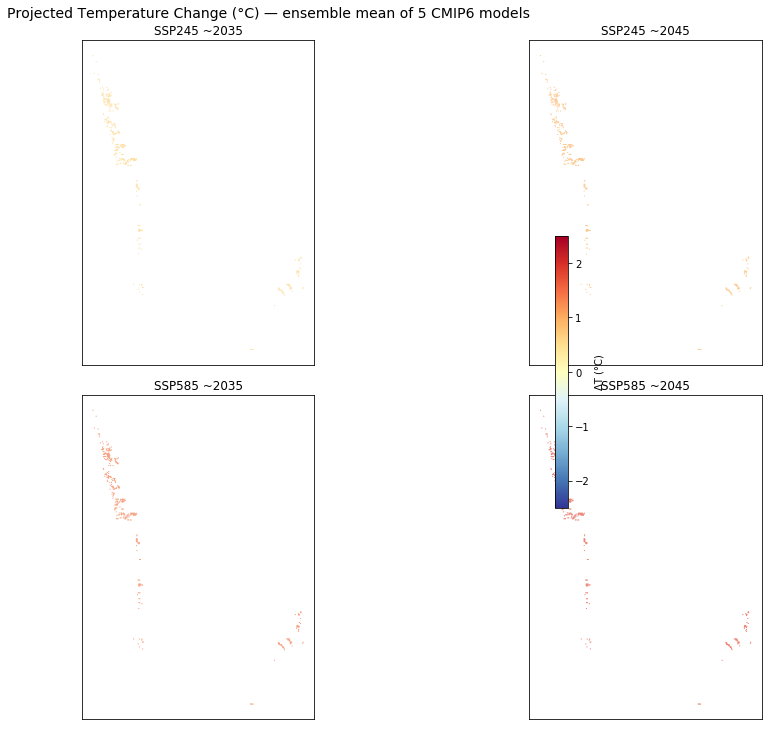

Saved ../img/08_delta_temp.png


In [13]:
# ── Delta map visualisation — temperature change ───────────────────────────────
import geopandas as gpd

grid = pd.read_pickle(f'{DATA}/polygons/kona_grid.pkl')
coffee_ids = baseline['plot_id'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Projected Temperature Change (°C) — ensemble mean of 5 CMIP6 models',
             fontsize=14, y=1.01)

vmax = 2.5
cmap = 'RdYlBu_r'

for ax_row, scenario in enumerate(SCENARIOS):
    for ax_col, horizon in enumerate(HORIZONS):
        ax = axes[ax_row][ax_col]
        feat = future_features[scenario][horizon]
        merged = grid[grid['plot_id'].isin(coffee_ids)].merge(
            feat[['plot_id', 'temp_mean']].rename(columns={'temp_mean': 'temp_future'}),
            on='plot_id', how='left'
        ).merge(
            baseline[['plot_id', 'temp_mean']].rename(columns={'temp_mean': 'temp_base'}),
            on='plot_id', how='left'
        )
        merged['delta_t'] = merged['temp_future'] - merged['temp_base']
        gdf_m = gpd.GeoDataFrame(merged, geometry='geometry', crs='EPSG:4326')
        gdf_m.plot(ax=ax, column='delta_t', cmap=cmap,
                   vmin=-vmax, vmax=vmax, legend=False,
                   edgecolor='none', alpha=0.85)
        ax.set_aspect(1 / np.cos(np.radians(19.6)))
        ax.set_title(f'{scenario.upper()} ~{horizon}', fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=-vmax, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.5, label='ΔT (°C)', pad=0.02)
plt.tight_layout()
plt.savefig('../img/08_delta_temp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ../img/08_delta_temp.png')

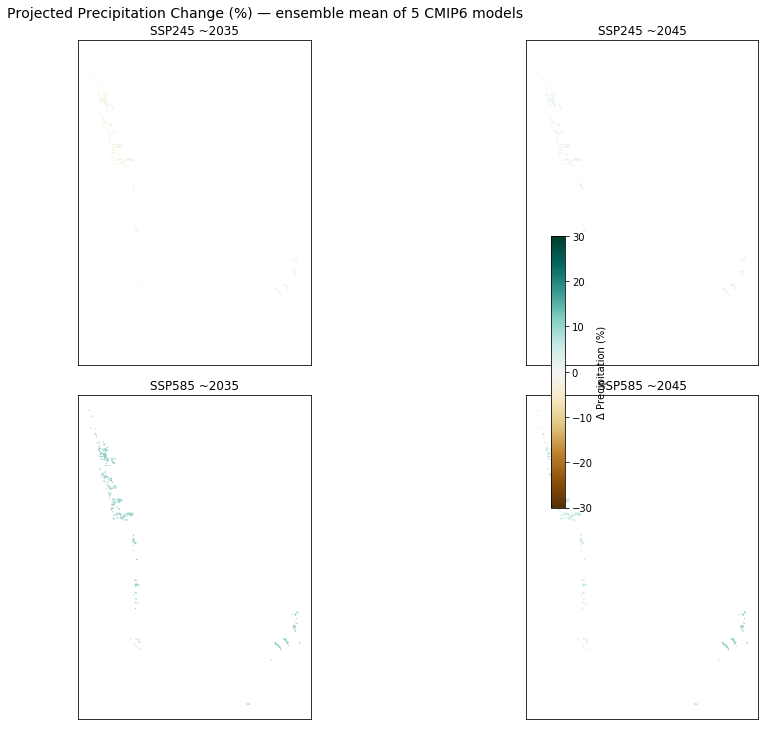

Saved ../img/08_delta_precip.png


In [14]:
# ── Precip change map ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Projected Precipitation Change (%) — ensemble mean of 5 CMIP6 models',
             fontsize=14, y=1.01)

for ax_row, scenario in enumerate(SCENARIOS):
    for ax_col, horizon in enumerate(HORIZONS):
        ax = axes[ax_row][ax_col]
        feat = future_features[scenario][horizon]
        merged = grid[grid['plot_id'].isin(coffee_ids)].merge(
            feat[['plot_id', 'precip_annual']].rename(columns={'precip_annual': 'precip_future'}),
            on='plot_id', how='left'
        ).merge(
            baseline[['plot_id', 'precip_annual']].rename(columns={'precip_annual': 'precip_base'}),
            on='plot_id', how='left'
        )
        merged['pct_change'] = 100 * (merged['precip_future'] / (merged['precip_base'] + 1e-9) - 1)
        gdf_m = gpd.GeoDataFrame(merged, geometry='geometry', crs='EPSG:4326')
        gdf_m.plot(ax=ax, column='pct_change', cmap='BrBG',
                   vmin=-30, vmax=30, legend=False,
                   edgecolor='none', alpha=0.85)
        ax.set_aspect(1 / np.cos(np.radians(19.6)))
        ax.set_title(f'{scenario.upper()} ~{horizon}', fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])

sm = plt.cm.ScalarMappable(cmap='BrBG', norm=mcolors.Normalize(vmin=-30, vmax=30))
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.5, label='Δ Precipitation (%)', pad=0.02)
plt.tight_layout()
plt.savefig('../img/08_delta_precip.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ../img/08_delta_precip.png')

In [15]:
# ── Output inventory ──────────────────────────────────────────────────────────
print('Files produced by this notebook:')
for scenario in SCENARIOS:
    for horizon in HORIZONS:
        for fname in [
            f'plot_climate_features_{scenario}_{horizon}.pkl',
            f'climate_deltas_{scenario}_{horizon}.pkl',
        ]:
            fpath = os.path.join(DATA, fname)
            exists = os.path.exists(fpath)
            size_kb = os.path.getsize(fpath) // 1024 if exists else 0
            print(f'  {"OK" if exists else "MISSING":6s}  {fname}  ({size_kb} KB)')

print()
print('Next step: run 04_similarity_search.ipynb Part D to score coffee suitability')
print('           under each future climate scenario.')

Files produced by this notebook:
  OK      plot_climate_features_ssp245_2035.pkl  (55 KB)
  OK      climate_deltas_ssp245_2035.pkl  (217 KB)
  OK      plot_climate_features_ssp245_2045.pkl  (55 KB)
  OK      climate_deltas_ssp245_2045.pkl  (217 KB)
  OK      plot_climate_features_ssp585_2035.pkl  (55 KB)
  OK      climate_deltas_ssp585_2035.pkl  (217 KB)
  OK      plot_climate_features_ssp585_2045.pkl  (55 KB)
  OK      climate_deltas_ssp585_2045.pkl  (217 KB)

Next step: run 04_similarity_search.ipynb Part D to score coffee suitability
           under each future climate scenario.
